## Δημήτριος Μουταφτσίδης 9920 (ΤΗΜΜΥ)
##### moutdimi@ece.auth.gr

In [3]:
import numpy as np

import torch
import torchvision
from torchvision import datasets

from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt

import random as rnd
import time

Update paths accordingly or ignore completely. The dataset was downloaded directly from the torchvision library.

In [5]:
training_set = datasets.CIFAR10(root = r"C:\Users\dimit\Desktop\Νευρωνικά\Εργασία 1",
                               train = True,  #Designating as training set.
                               download = True,
                               transform = None)   

test_set = datasets.CIFAR10(root = r"C:\Users\dimit\Desktop\Νευρωνικά\Εργασία 1",
                            train = False,   #Designating as test set.
                            download = True,   
                            transform = None)

Extracting training/test sets and corresponding labels.

In [7]:
I_train = training_set.data   #Using the .data extension to separate training data. They are in the form of a numpy array.
L_train = np.array(training_set.targets)   #.targets yields a list of integers. We convert to numpy array.

I_test = test_set.data
L_test = np.array(test_set.targets)

Identifying labels, names and counts for each class. Printing for a quick sanity check.

In [9]:
num_classes = len(np.unique(L_train))   #The length of the unique label list is ,of course, the number of different classes.
class_labels , class_counts = np.unique(L_train , return_counts = True)   #np.unique can return counts of each instance as well.
classes = training_set.classes   #The .classses extension returns the designated names for each class, corresponding to each label.
class_label_corr = dict(zip(class_labels , classes))   #We zip to a dictionary for name-label correspondance.

In [10]:
print("Training data shape: ", I_train.shape , "\n")
print("Test data shape: ",I_test.shape , "\n")

print("Training labels shape: ",L_train.shape, "\n")
print("Test labels shape: ", L_test.shape , "\n")

print("Number of classes: ", num_classes , "\n")
print("Class labels: ", class_labels , "\n")

print("Actual class names: ", classes , "\n")

print("Class-Label correspondance : " , class_label_corr, "\n")

print("Number of instances per class (training set):\n")
for x, y in zip(classes, class_counts):
    print(f"{x:>10s}: {y}")   #We reserve 10 charactes for a neat print result.

Training data shape:  (50000, 32, 32, 3) 

Test data shape:  (10000, 32, 32, 3) 

Training labels shape:  (50000,) 

Test labels shape:  (10000,) 

Number of classes:  10 

Class labels:  [0 1 2 3 4 5 6 7 8 9] 

Actual class names:  ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'] 

Class-Label correspondance :  {0: 'airplane', 1: 'automobile', 2: 'bird', 3: 'cat', 4: 'deer', 5: 'dog', 6: 'frog', 7: 'horse', 8: 'ship', 9: 'truck'} 

Number of instances per class (training set):

  airplane: 5000
automobile: 5000
      bird: 5000
       cat: 5000
      deer: 5000
       dog: 5000
      frog: 5000
     horse: 5000
      ship: 5000
     truck: 5000


Normalizing data to 0-1 scale on float32 format. float32 makes numerical results more precise. It is not as kind to execution time and memory usage. However for the needs of this assignment it is no problem at all.

In [12]:
I_train = I_train.astype(np.float32) / 255.0   #[0 , 255] / 255 yields the normalized [0,1] scale.
I_test  = I_test.astype(np.float32) / 255.0

Run the following cell multiple times to visually inspect images.

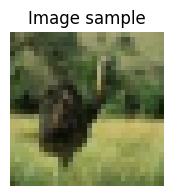

In [43]:
image_num = rnd.randint(0 , 50000)   #Pick a random image.

plt.figure(figsize = (2 , 2))
plt.imshow(I_train[image_num])   #Use pyplot's imshow to depict said image.
plt.title("Image sample")
plt.axis("off")
plt.show() 

Creating a bar graph of the average intensity of each colour channel for all class images. The 'axis = 0 , 1 , 2' command produces a vector of length 3, containg mean-R value, mean-G value and mean-B values for all images of the particular class. We iterate through all classes, extract mask of indices for instances of the particular class and then use it to isolate images in each iteration.

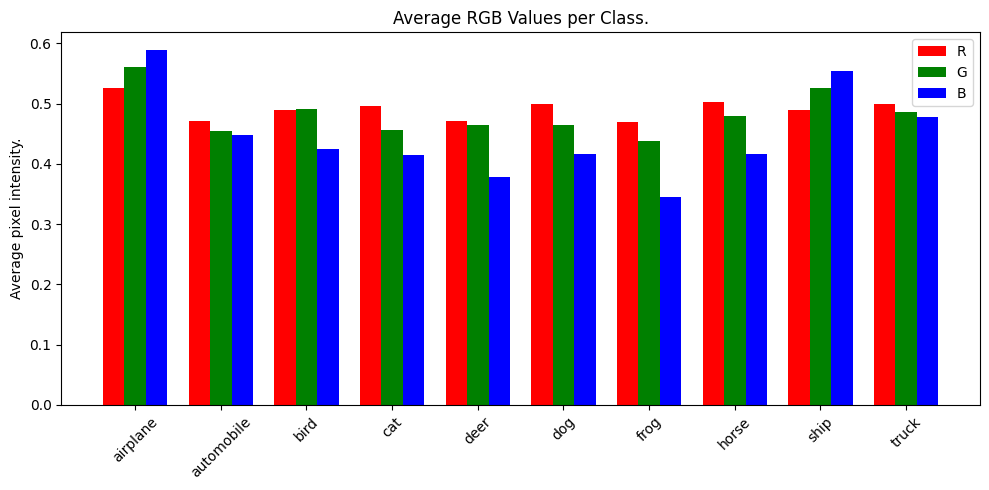

In [188]:
average_rgb = np.zeros((num_classes , 3))   #Preallocate 10x3 empty numpy array using np.zeros.

for i in range(num_classes):   #Iterate through all classes.
    class_id = (L_train == i)   #Identify image indices for particular class.
    class_images = I_train[class_id]   #Apply mask to select only images from class i.
    average_rgb[i] = class_images.mean(axis = (0 , 1 , 2))   #.mean extension produces a 3x1 vector containing the average of each R,G and B value.

x = np.arange(num_classes)

plt.figure(figsize=(10,5))
plt.bar(x - 0.25 , average_rgb[: , 0] , 0.25 , color = 'r', label = 'R')    #Pyplot's .bar gives us the bar graph. We shift by a bar length to avoid bar overlap.
plt.bar(x , average_rgb[: , 1] , 0.25 , color = 'g', label= 'G')
plt.bar(x + 0.25 , average_rgb[: , 2], 0.25 , color = 'b', label = 'B')

plt.xticks(x , classes , rotation = 45)   #Print x-axis labels diagonally for style points.
plt.ylabel('Average pixel intensity.')
plt.title('Average RGB Values per Class.')
plt.legend()
plt.tight_layout()
plt.show()

Producing the average colour plot by creating 10x10 white images with 3 channels and multiplying by the average RGB value vector.

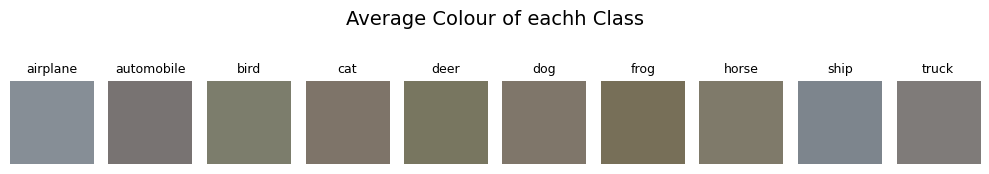

In [190]:
plt.figure(figsize=(10, 2))

for i, (name, color) in enumerate(zip(classes, average_rgb)):   #Enumaration iterates through the Class - Average RGB tuple as well as through the index.
    plt.subplot(1 , num_classes, i + 1)                         
    plt.imshow(np.ones((10 , 10 , 3)) * color)   #Create a 10x10 image of ones and scale according to the colour profile of each class.
    plt.title(name , fontsize = 9)
    plt.axis("off")

plt.suptitle("Average Colour of eachh Class", fontsize = 14)
plt.tight_layout()
plt.show()

Producing the "Average Instance" plot for each class.

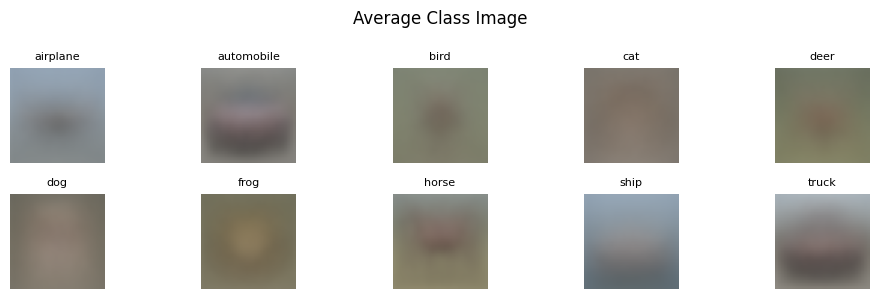

In [194]:
average_images = []   #Pre-allocating the array for computational efficiency.
for class_index, class_name in enumerate(classes):   #We talked about enumeration earlier.
    mask = (L_train == class_index)    #Same indexing and mask extraction process as before.
    images = I_train[mask]
    average_image = images.mean(axis = 0)   #Axis = 0 reffers to the first dimension of the 4D array. Thus, it averages out across images, 
    average_images.append(average_image)    #while preserving spatial structure.


plt.figure(figsize=(10, 3))
for i, (class_name, image) in enumerate(zip(classes, average_images)):
    plt.subplot(2 , 5 , i + 1)
    plt.imshow(image)
    plt.title(class_name, fontsize = 8)
    plt.axis("off")
plt.suptitle("Average Class Image", fontsize = 12)
plt.tight_layout()
plt.show()

Time for k-NN implementation. We need to flatten the data first.

In [197]:
I_train = I_train.reshape(I_train.shape[0] , -1)   #(50000, 32, 32, 3) -> (50000, 3072)
I_test = I_test.reshape(I_test.shape[0] , -1)   #(10000, 32, 32, 3) -> (10000, 3072)

First 1-NN.

In [200]:
start_time = time.time()   #Let's time the procedure.

kNN1 = KNeighborsClassifier(n_neighbors = 1, n_jobs = -1)   #Use sickitlearn's built in k-NN classifier module. Requesting all cores.
kNN1.fit(I_train , L_train)    #Training step.

training_time = time.time()

L_pred_1 = kNN1.predict(I_test)   #Classification step.

end_time = time.time()

accuracy_1 = accuracy_score(L_test, L_pred_1)   #Extract the accuracy metric.

print("1-NN accuracy:", accuracy_1 , "\n")
print("Training time for 1-NN: " , training_time - start_time , "\n")
print("Classification time for 1-NN: " , end_time - training_time , "\n")

print("Detailed classification report for 1-NN:\n")
print(classification_report(L_test , L_pred_1 , target_names = classes))    #Requesting the built-in classification report.

1-NN accuracy: 0.3539 

Training time for 1-NN:  0.4795682430267334 

Classification time for 1-NN:  21.994513273239136 

Detailed classification report for 1-NN:

              precision    recall  f1-score   support

    airplane       0.42      0.48      0.45      1000
  automobile       0.65      0.22      0.33      1000
        bird       0.24      0.38      0.30      1000
         cat       0.29      0.24      0.26      1000
        deer       0.25      0.46      0.32      1000
         dog       0.36      0.29      0.32      1000
        frog       0.33      0.35      0.34      1000
       horse       0.56      0.29      0.39      1000
        ship       0.40      0.62      0.49      1000
       truck       0.61      0.20      0.30      1000

    accuracy                           0.35     10000
   macro avg       0.41      0.35      0.35     10000
weighted avg       0.41      0.35      0.35     10000



A very useful metric is the confusion matrix. We can request it from the built-in confusion_matrix module.

Confusion matrix shape: (10, 10) 



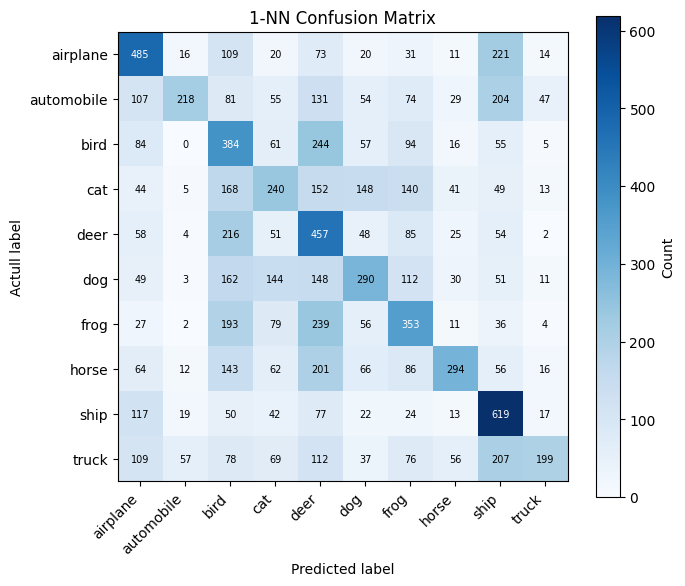


Per-class accuracy for 1-NN: 
  airplane:  48.50%
automobile:  21.80%
      bird:  38.40%
       cat:  24.00%
      deer:  45.70%
       dog:  29.00%
      frog:  35.30%
     horse:  29.40%
      ship:  61.90%
     truck:  19.90%


In [202]:
c_m_1 = confusion_matrix(L_test , L_pred_1)  #Comments are redundant here, most of the code is essentially printing.

print("Confusion matrix shape:", c_m_1.shape , "\n")

plt.figure(figsize = (7 , 6))
plt.imshow(c_m_1 , cmap = 'Blues')
plt.colorbar(label = "Count")

plt.xticks(np.arange(len(classes)) , classes, rotation = 45 , ha="right")
plt.yticks(np.arange(len(classes)), classes)
plt.xlabel("Predicted label")
plt.ylabel("Actull label")
plt.title("1-NN Confusion Matrix")

for i in range(c_m_1.shape[0]):
    for j in range(c_m_1.shape[1]):
        value = c_m_1[i , j]
        color = "white" if value > c_m_1.max() * 0.5 else "black"
        plt.text(j , i, str(value), ha = "center" , va = "center", color = color, fontsize = 7)

plt.tight_layout()
plt.show()

true_per_class_1 = c_m_1.sum(axis = 1)
correct_per_class_1 = np.diag(c_m_1)
per_class_accuracy_1 = correct_per_class_1 / (true_per_class_1 + 1e-8)   #Essentially the recall but with more decimals.

print("\nPer-class accuracy for 1-NN: ")
for class_name , acc in zip(classes , per_class_accuracy_1):
    print(f"{class_name : >10s}: {acc * 100 : .2f}%")

We proceed with 3-NN.

In [204]:
start_time = time.time()   #Let's time the procedure.

kNN3 = KNeighborsClassifier(n_neighbors = 3, n_jobs = -1)   #Use sickitlearn's built in k-NN classifier module. Requesting all cores.
kNN3.fit(I_train , L_train)    #Training step.

training_time = time.time()

L_pred = kNN3.predict(I_test)   #Classification step.

end_time = time.time()

accuracy = accuracy_score(L_test, L_pred)   #Extract the accuracy metric.

print("3-NN accuracy:", accuracy , "\n")
print("Training time for 3-NN: " , training_time - start_time , "\n")
print("Classification time for 3-NN: " , end_time - training_time , "\n")

print("Detailed classification report for 3-NN:\n")
print(classification_report(L_test , L_pred , target_names = classes))  #Requesting the built-in classification report.

3-NN accuracy: 0.3303 

Training time for 3-NN:  0.23201370239257812 

Classification time for 3-NN:  22.278167486190796 

Detailed classification report for 3-NN:

              precision    recall  f1-score   support

    airplane       0.32      0.57      0.41      1000
  automobile       0.58      0.24      0.34      1000
        bird       0.20      0.45      0.28      1000
         cat       0.26      0.23      0.24      1000
        deer       0.25      0.44      0.32      1000
         dog       0.43      0.21      0.28      1000
        frog       0.36      0.23      0.28      1000
       horse       0.73      0.20      0.31      1000
        ship       0.44      0.61      0.51      1000
       truck       0.73      0.12      0.21      1000

    accuracy                           0.33     10000
   macro avg       0.43      0.33      0.32     10000
weighted avg       0.43      0.33      0.32     10000



Confusion matrix shape: (10, 10) 



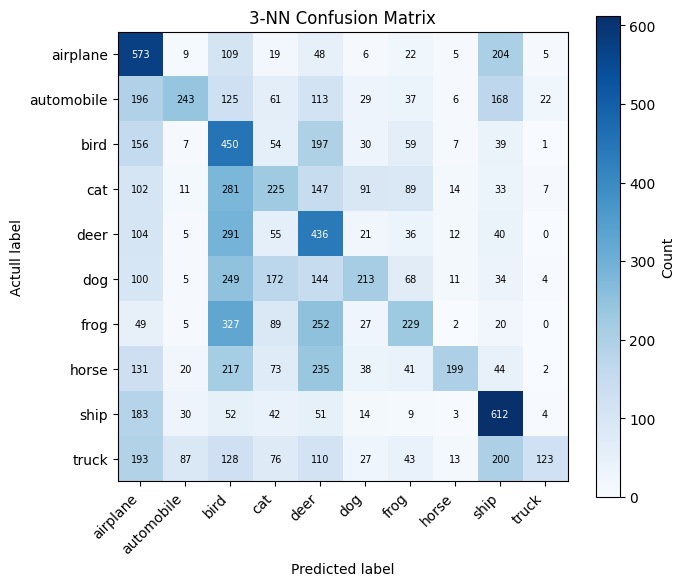


Per-class accuracy for 3-NN: 
  airplane:  57.30%
automobile:  24.30%
      bird:  45.00%
       cat:  22.50%
      deer:  43.60%
       dog:  21.30%
      frog:  22.90%
     horse:  19.90%
      ship:  61.20%
     truck:  12.30%


In [205]:
c_m = confusion_matrix(L_test , L_pred)   #Comments are redundant here, most of the code is essentially printing.

print("Confusion matrix shape:", c_m.shape , "\n")

plt.figure(figsize = (7 , 6))
plt.imshow(c_m , cmap = 'Blues')
plt.colorbar(label = "Count")

plt.xticks(np.arange(len(classes)) , classes, rotation = 45 , ha="right")
plt.yticks(np.arange(len(classes)), classes)
plt.xlabel("Predicted label")
plt.ylabel("Actull label")
plt.title("3-NN Confusion Matrix")

for i in range(c_m.shape[0]):
    for j in range(c_m.shape[1]):
        value = c_m[i , j]
        color = "white" if value > c_m.max() * 0.5 else "black"
        plt.text(j , i, str(value), ha = "center" , va = "center", color = color, fontsize = 7)

plt.tight_layout()
plt.show()


true_per_class = c_m.sum(axis = 1)
correct_per_class = np.diag(c_m)
per_class_accuracy = correct_per_class / (true_per_class + 1e-8)   #Essentially the recall but with more decimals.

print("\nPer-class accuracy for 3-NN: ")
for class_name , acc in zip(classes , per_class_accuracy):
    print(f"{class_name : >10s}: {acc * 100 : .2f}%")

We proceed to use the Cosine Distance Metric. The process is the exact same as before. 

In [207]:
start_time = time.time()   #Let's time the procedure.

kNN1C = KNeighborsClassifier(n_neighbors = 1 , metric = 'cosine' , n_jobs = -1)   #Use sickitlearn's built in k-NN classifier module. Requesting Cosine Dist. Metric.
kNN1C.fit(I_train , L_train)    #Training step.

training_time = time.time()

L_pred_1C = kNN1C.predict(I_test)   #Classification step.

end_time = time.time()

accuracy_1C = accuracy_score(L_test, L_pred_1C)   #Extract the accuracy metric.

print("1-NN accuracy:", accuracy_1C , "\n")
print("Training time for 1-NN: " , training_time - start_time , "\n")
print("Classification time for 1-NN: " , end_time - training_time , "\n")

print("Detailed classification report for 1-NN with Cosine Distance:\n")
print(classification_report(L_test , L_pred_1C , target_names = classes))    #Requesting the built-in classification report.

1-NN accuracy: 0.3672 

Training time for 1-NN:  0.27028989791870117 

Classification time for 1-NN:  12.188539981842041 

Detailed classification report for 1-NN with Cosine Distance:

              precision    recall  f1-score   support

    airplane       0.40      0.52      0.45      1000
  automobile       0.65      0.28      0.39      1000
        bird       0.27      0.35      0.31      1000
         cat       0.26      0.26      0.26      1000
        deer       0.29      0.41      0.34      1000
         dog       0.32      0.31      0.32      1000
        frog       0.37      0.32      0.34      1000
       horse       0.55      0.32      0.41      1000
        ship       0.38      0.66      0.49      1000
       truck       0.58      0.25      0.35      1000

    accuracy                           0.37     10000
   macro avg       0.41      0.37      0.36     10000
weighted avg       0.41      0.37      0.36     10000



Confusion matrix shape: (10, 10) 



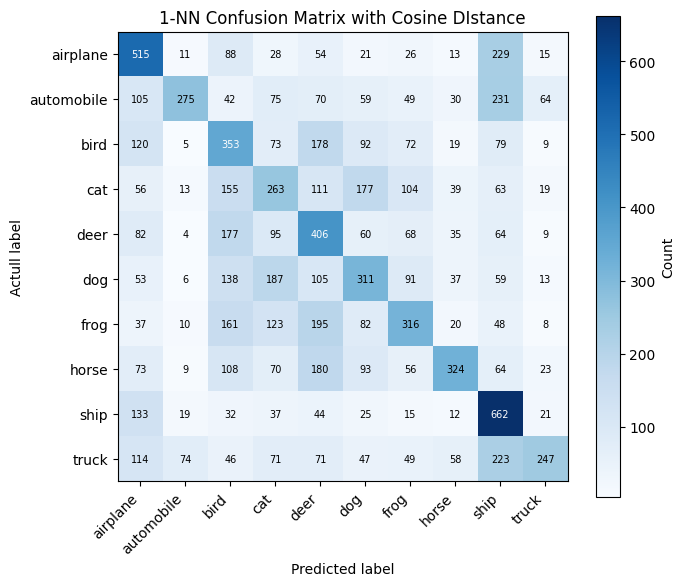

In [208]:
c_m_1C= confusion_matrix(L_test , L_pred_1C)  #Comments are redundant here, most of the code is essentially printing.

print("Confusion matrix shape:", c_m_1C.shape , "\n")

plt.figure(figsize = (7 , 6))
plt.imshow(c_m_1C , cmap = 'Blues')
plt.colorbar(label = "Count")

plt.xticks(np.arange(len(classes)) , classes, rotation = 45 , ha="right")
plt.yticks(np.arange(len(classes)), classes)
plt.xlabel("Predicted label")
plt.ylabel("Actull label")
plt.title("1-NN Confusion Matrix with Cosine DIstance")

for i in range(c_m_1C.shape[0]):
    for j in range(c_m_1C.shape[1]):
        value = c_m_1C[i , j]
        color = "white" if value > c_m_1C.max() * 0.5 else "black"
        plt.text(j , i, str(value), ha = "center" , va = "center", color = color, fontsize = 7)

plt.tight_layout()
plt.show()


We now proceed with the NCC. Sickitlearn offers a built-in module once again. We can include metric = 'manhattan' if we wish to use Manhattan Distance instead.

In [226]:
start_time = time.time()
    
NCC = NearestCentroid()
NCC.fit(I_train, L_train)

train_end = time.time()

L_pred_NCC = NCC.predict(I_test)

end_time = time.time()

accuracy_NCC = accuracy_score(L_test , L_pred_NCC)
print("Nearest Centroid accuracy: " , accuracy_NCC , "\n")
print("Training time for NCC: ", train_end - start_time, "\n")
print("Classification time NCC: ", end_time - train_end, "\n")

print("Classification report for Nearest Centroid: \n")
print(classification_report(L_test , L_pred_NCC , target_names = classes))

Nearest Centroid accuracy:  0.2774 

Training time for NCC:  0.881990909576416 

Classification time NCC:  0.32459521293640137 

Classification report for Nearest Centroid: 

              precision    recall  f1-score   support

    airplane       0.27      0.54      0.36      1000
  automobile       0.28      0.19      0.22      1000
        bird       0.28      0.11      0.16      1000
         cat       0.27      0.06      0.09      1000
        deer       0.28      0.12      0.17      1000
         dog       0.27      0.29      0.28      1000
        frog       0.22      0.54      0.31      1000
       horse       0.27      0.17      0.20      1000
        ship       0.42      0.37      0.39      1000
       truck       0.33      0.41      0.36      1000

    accuracy                           0.28     10000
   macro avg       0.29      0.28      0.25     10000
weighted avg       0.29      0.28      0.25     10000



Confusion matrix shape: (10, 10) 



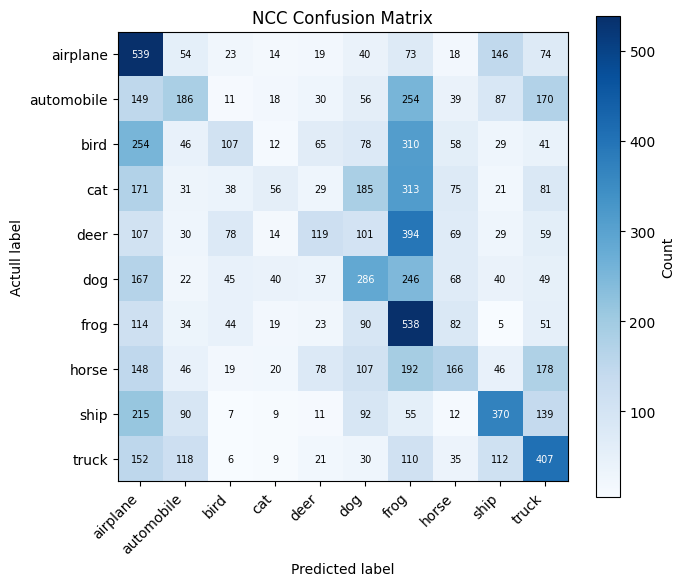

In [220]:
c_m_NCC= confusion_matrix(L_test , L_pred_NCC)  #Comments are redundant here, most of the code is essentially printing.

print("Confusion matrix shape:", c_m_NCC.shape , "\n")

plt.figure(figsize = (7 , 6))
plt.imshow(c_m_NCC , cmap = 'Blues')
plt.colorbar(label = "Count")

plt.xticks(np.arange(len(classes)) , classes, rotation = 45 , ha="right")
plt.yticks(np.arange(len(classes)), classes)
plt.xlabel("Predicted label")
plt.ylabel("Actull label")
plt.title("NCC Confusion Matrix")

for i in range(c_m_NCC.shape[0]):
    for j in range(c_m_NCC.shape[1]):
        value = c_m_NCC[i , j]
        color = "white" if value > c_m_NCC.max() * 0.5 else "black"
        plt.text(j , i, str(value), ha = "center" , va = "center", color = color, fontsize = 7)

plt.tight_layout()
plt.show()

For the final act, we perform a manual Grid Search with varying Numbers of Principal Components and include all of our previous classifiers. We print the results for the winner. The sickitlearn library contains a built-in PCA module. Takes some time to run.

In [236]:
models = {"1-NN Euc" : KNeighborsClassifier(n_neighbors = 1 , n_jobs = -1) , 
         "1-NN Cos" : KNeighborsClassifier(n_neighbors = 1 , metric = 'cosine' , n_jobs = -1) ,
         "3-NN Euc" : KNeighborsClassifier(n_neighbors = 3 , n_jobs = -1) , 
         "3-NN Cos" : KNeighborsClassifier(n_neighbors = 3 , metric = 'cosine' , n_jobs = -1) ,
         "NCC":  NearestCentroid()}   #Creating model name -> model dictionary to iterate over.

PCA_dimensions = [20 , 50 , 60 , 80 , 90 , 120 , 200]   #Creating PCA dimensions list.

results = []   #Preallocating for efficiency.

for dim in PCA_dimensions:   #First loop for PCA dimension list.

    pca = PCA(n_components = dim)   #Using built-in PCA module.
    I_train_pca = pca.fit_transform(I_train)   #Apllying to training data.
    I_test_pca = pca.transform(I_test)   #Applying to test data.

    pca_version = f"PCA_{dim}"

    for model_name , model in models.items():   #Now extracting accuracy scores by iterating through models.
        model.fit(I_train_pca , L_train)
        L_pred_gs = model.predict(I_test_pca)
        accuracy_gs = accuracy_score(L_test , L_pred_gs)
        results.append((pca_version , model_name , accuracy_gs))

results_sorted = sorted(results , key = lambda x: x[2] , reverse=True)
print("Results of Grid Search: \n")
for r in results_sorted:
    print(f"PCA = {r[0]:10s}  |  {r[1]:10s}  |  acc={r[2]:.4f}")
    

Results of Grid Search: 

PCA = PCA_80      |  1-NN Cos    |  acc=0.4234
PCA = PCA_90      |  1-NN Cos    |  acc=0.4226
PCA = PCA_60      |  1-NN Cos    |  acc=0.4222
PCA = PCA_120     |  1-NN Cos    |  acc=0.4220
PCA = PCA_200     |  1-NN Cos    |  acc=0.4206
PCA = PCA_90      |  3-NN Cos    |  acc=0.4184
PCA = PCA_50      |  1-NN Cos    |  acc=0.4167
PCA = PCA_120     |  3-NN Cos    |  acc=0.4167
PCA = PCA_80      |  3-NN Cos    |  acc=0.4164
PCA = PCA_60      |  3-NN Cos    |  acc=0.4143
PCA = PCA_200     |  3-NN Cos    |  acc=0.4129
PCA = PCA_50      |  3-NN Cos    |  acc=0.4086
PCA = PCA_60      |  1-NN Euc    |  acc=0.3943
PCA = PCA_50      |  1-NN Euc    |  acc=0.3892
PCA = PCA_80      |  1-NN Euc    |  acc=0.3881
PCA = PCA_90      |  1-NN Euc    |  acc=0.3880
PCA = PCA_20      |  3-NN Cos    |  acc=0.3852
PCA = PCA_120     |  1-NN Euc    |  acc=0.3822
PCA = PCA_20      |  1-NN Cos    |  acc=0.3768
PCA = PCA_50      |  3-NN Euc    |  acc=0.3761
PCA = PCA_60      |  3-NN Euc    |